<a href="https://colab.research.google.com/github/hridibazaman03/220142_SVM/blob/main/220142_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

In [52]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
df = pd.read_csv('/content/drive/MyDrive/ML Datasets/heart.csv')

In [54]:
print(df.head())
print(df.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

In [55]:
num_cols = df.select_dtypes(include=np.number).columns

In [56]:
imputer = SimpleImputer(strategy='mean')

In [57]:
df[num_cols] = imputer.fit_transform(df[num_cols])

In [58]:
X = df.drop('target', axis=1)

In [59]:
y = df['target']

In [60]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [61]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [62]:
scaler = StandardScaler()

In [63]:
X_train = scaler.fit_transform(X_train)

In [64]:
X_val = scaler.transform(X_val)

In [65]:
X_test = scaler.transform(X_test)

In [66]:
svm_model = SVC(probability=True)

In [67]:
svm_model.fit(X_train, y_train)

SVC(probability=True)

In [68]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'degree': [2, 3]
}

In [69]:
grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [70]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10], 'degree': [2, 3],
                         'gamma': ['scale', 0.1, 0.01],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [71]:
print(grid.best_params_)

{'C': 10, 'degree': 3, 'gamma': 0.1, 'kernel': 'poly'}


In [72]:
best_svm = grid.best_estimator_

In [73]:
y_pred = best_svm.predict(X_test)

In [74]:
y_prob = best_svm.predict_proba(X_test)[:,1]

In [75]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.987012987012987


In [76]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 1.0


In [77]:
print("Recall   :", recall_score(y_test, y_pred))

Recall   : 0.9770114942528736


In [78]:
print("F1 Score :", f1_score(y_test, y_pred))

F1 Score : 0.9883720930232558


In [79]:
print("AUC Score:", roc_auc_score(y_test, y_prob))

AUC Score: 0.9987991079087322


In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99        67
         1.0       1.00      0.98      0.99        87

    accuracy                           0.99       154
   macro avg       0.99      0.99      0.99       154
weighted avg       0.99      0.99      0.99       154



In [81]:
cm = confusion_matrix(y_test, y_pred)

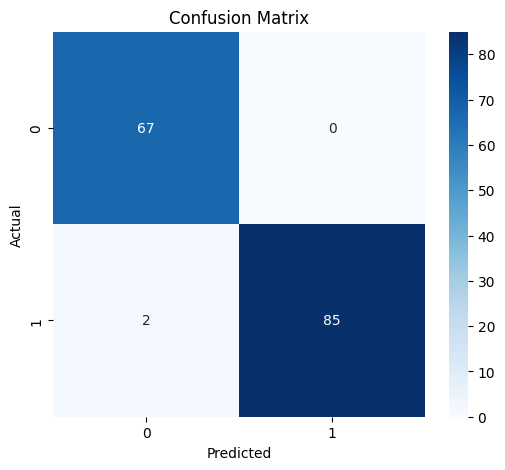

In [82]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [83]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

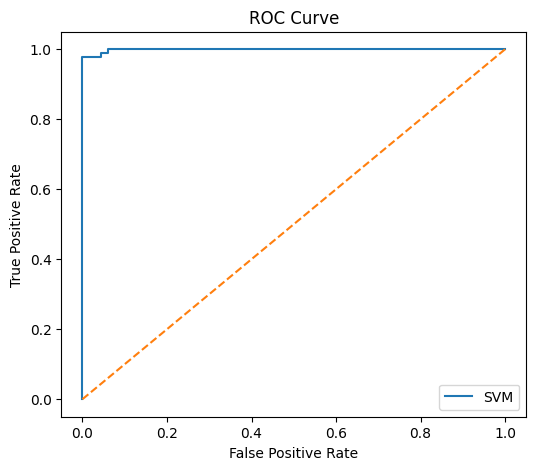

In [84]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label='SVM')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [85]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})
print(results.head(10))

   Actual  Predicted   Probability
0     0.0        0.0  8.954627e-04
1     0.0        0.0  7.980627e-07
2     0.0        0.0  2.863119e-03
3     1.0        1.0  9.420738e-01
4     1.0        1.0  9.969395e-01
5     1.0        1.0  9.421807e-01
6     1.0        1.0  9.421232e-01
7     1.0        1.0  9.421901e-01
8     0.0        0.0  7.062518e-07
9     0.0        0.0  3.733212e-02


In [86]:
X2 = X.iloc[:, :2]

In [87]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y,
    test_size=0.30,
    random_state=42
)

In [88]:
scaler2 = StandardScaler()

In [89]:
X2_train = scaler2.fit_transform(X2_train)

In [90]:
X2_test = scaler2.transform(X2_test)

In [91]:
svm2 = SVC(kernel='rbf')

In [92]:
svm2.fit(X2_train, y2_train)

SVC()

In [93]:
x1, x2 = np.meshgrid(
    np.arange(
        X2_train[:,0].min()-1,
        X2_train[:,0].max()+1,
        0.01
    ),
    np.arange(
        X2_train[:,1].min()-1,
        X2_train[:,1].max()+1,
        0.01
    )
)

In [94]:
Z = svm2.predict(
    np.array([x1.ravel(), x2.ravel()]).T
)

In [95]:
Z = Z.reshape(x1.shape)

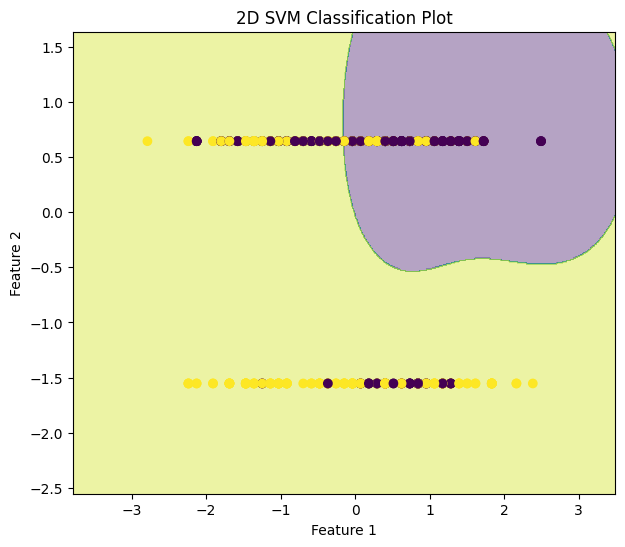

In [96]:
plt.figure(figsize=(7,6))

plt.contourf(x1, x2, Z, alpha=0.4)

plt.scatter(
    X2_train[:,0],
    X2_train[:,1],
    c=y2_train
)

plt.title("2D SVM Classification Plot")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()